<img src="Local\imgs\U1\banner_fcd.jpg" alt="banner" width="1100"  height="150">

# <span style="color:black;"><strong>Técnicas de detección de atípicos</strong></span>  
---
<p align="right">
  <a href="https://colab.research.google.com/github/mariabda2/intro_data_2026/blob/main/FCD_U3_2_deteccion_atipicos_tecnicas.ipynb?clone=true" target="_blank">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Abrir en Colab"/>
  </a>
</p>

## <span style="color:#2F749F;"><strong>🎯 Objetivos de aprendizaje</strong></span>

> ✅ Comprender el concepto de **dato atípico** y su importancia en el análisis estadístico y en proyectos de ciencia de datos.  
>  
> ✅ Identificar y aplicar diferentes **técnicas de detección de atípicos** en datos univariados y multivariados (gráficas, métodos estadísticos y enfoques basados en modelos).  
>  
> ✅ Analizar el impacto de los atípicos en la **calidad de los modelos predictivos y descriptivos**, evaluando riesgos y sesgos asociados.  
>  
> ✅ Desarrollar criterios para decidir **cuándo corregir, transformar o conservar los datos atípicos**, según el contexto y los objetivos del análisis.  
>  
> ✅ Implementar métodos de detección de atípicos en **ejercicios prácticos con Python**, fortaleciendo la capacidad de limpiar y preparar datos de forma crítica.  


## <span style="color:#2F749F;"><strong>Contenido</strong></span>

1. **Métodos estadísticos**  
   - Rango intercuartílico (IQR)  
   - Puntaje Z (Z-Score)  
   - Test de Grubbs  
2. **Técnicas de visualización**  
   - Boxplot  
   - Scatter plot  
3. **Métodos basados en densidad y clustering**  
   - DBSCAN  
   - Local Outlier Factor (LOF)  
4. **Técnicas de aprendizaje automático**  
   - Isolation Forest  

In [55]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import zscore
from scipy import stats
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_blobs
from matplotlib.patches import Circle
from sklearn.neighbors import NearestNeighbors

sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'DejaVu Sans'
np.random.seed(42)

In [56]:
# Simulación de datos con outliers
normal_data = np.random.normal(loc=50, scale=10, size=100)
outliers = np.array([10, 120, 130])
data = np.concatenate([normal_data, outliers])
df = pd.DataFrame({'valor': data})

# <span style="color:#2F749F;"><strong>1. Método del Rango Intercuartílico (IQR)</strong></span>

El **IQR (Interquartile Range)** es una medida robusta de dispersión introducida por Tukey [(1977)](https://www.wiley.com/en-us/Exploratory+Data+Analysis-p-9780201076165).  
Se define como la diferencia entre el tercer cuartil \(Q_3\) y el primer cuartil \(Q_1\):

$$
\mathrm{IQR} = Q_3 - Q_1
$$

Un valor se considera atípico si se ubica fuera del rango:

$$
\left[\, Q_1 - 1.5\cdot\mathrm{IQR}, \;\; Q_3 + 1.5\cdot\mathrm{IQR} \,\right]
$$



<div style="background-color:#fff9db; padding:10px; border-radius:5px; font-size:18px;">
  <b>Este enfoque es simple, robusto frente a distribuciones asimétricas, pero menos eficaz en entornos multivariados. 
  Es recomendable complementarlo con otros métodos y con criterios contextuales antes de tomar decisiones sobre los datos atípicos.</b>
</div>

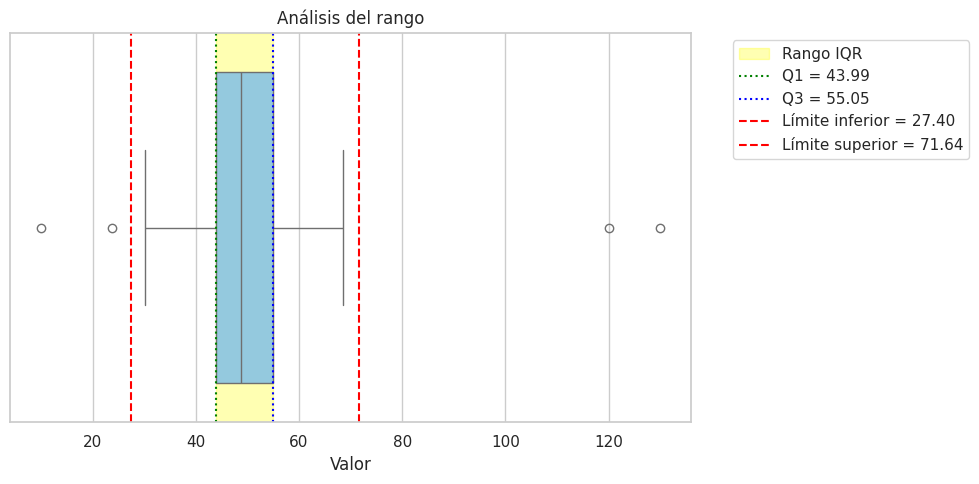

In [57]:
# Cálculo de IQR
Q1 = df['valor'].quantile(0.25)
Q3 = df['valor'].quantile(0.75)
IQR = Q3 - Q1
lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR
df['outlier_iqr'] = (df['valor'] < lim_inf) | (df['valor'] > lim_sup)

plt.figure(figsize=(10,5))
sns.boxplot(x=df['valor'], color='skyblue')
plt.axvspan(Q1, Q3, color='yellow', alpha=0.3, label='Rango IQR')
plt.axvline(Q1, color='green', linestyle=':', label=f'Q1 = {Q1:.2f}')
plt.axvline(Q3, color='blue', linestyle=':', label=f'Q3 = {Q3:.2f}')
plt.axvline(lim_inf, color='red', linestyle='--', label=f'Límite inferior = {lim_inf:.2f}')
plt.axvline(lim_sup, color='red', linestyle='--', label=f'Límite superior = {lim_sup:.2f}')

plt.xlabel('Valor')
plt.title('Análisis del rango')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


<div style="background-color:#e8f4fd; padding:15px; border-radius:8px; font-size:17px;">

<b>Importante (IQR):</b>

- **Sensibilidad al tamaño de muestra**: con conjuntos de datos pequeños, la estimación de los cuartiles puede ser inestable y afectar la detección de atípicos.  
- **Eficiencia en distribuciones no normales**: el IQR es robusto frente a sesgos y asimetrías, pero puede identificar como atípicos valores que en realidad son parte natural de una distribución sesgada.  
- **Umbral fijo (1.5 × IQR)**: el factor de 1.5 es convencional, pero no universal. Ajustar este valor puede ser necesario en contextos específicos (ej. usar 3 × IQR en datos muy dispersos).  
- **No captura relaciones multivariadas**: un valor puede no ser atípico en una sola variable, pero sí al considerar varias variables de manera conjunta. El IQR no detecta este tipo de casos.  
- **Interpretación contextual**: no todo valor extremo es necesariamente un error; algunos pueden reflejar fenómenos reales importantes (ej. un rendimiento académico excepcional).  

</div>

# <span style="color:#2F749F;"><strong>2. Método del Puntaje Z (Z-Score)</strong></span>

El **Z-score** indica la distancia en desviaciones estándar de un valor respecto a la media, siendo ampliamente descrito en Barnett y Lewis [(1994)](https://onlinelibrary.wiley.com/doi/book/10.1002/9781118490082).  
Para un valor \(x\):

$$
Z = \frac{x - \mu}{\sigma}
$$

Se considera atípico si:

$$
|Z| > k
$$

donde típicamente \(k = 3\). 

<div style="background-color:#fff9db; padding:10px; border-radius:5px; font-size:18px;">
  <b>Este método es apropiado cuando los datos se aproximan a una distribución normal, 
  pero puede verse afectado por la presencia de valores extremos o asimetrías que alteran 
  significativamente la media y la desviación estándar.</b><br>
</div>




       valor   z_score      media   desv_est
0  54.967142  0.342280  50.059743  14.337369
1  48.617357 -0.100603  50.059743  14.337369
2  56.476885  0.447582  50.059743  14.337369
3  65.230299  1.058113  50.059743  14.337369
4  47.658466 -0.167484  50.059743  14.337369
5  47.658630 -0.167472  50.059743  14.337369
6  65.792128  1.097299  50.059743  14.337369
7  57.674347  0.531102  50.059743  14.337369
8  45.305256 -0.331615  50.059743  14.337369
9  55.425600  0.374257  50.059743  14.337369


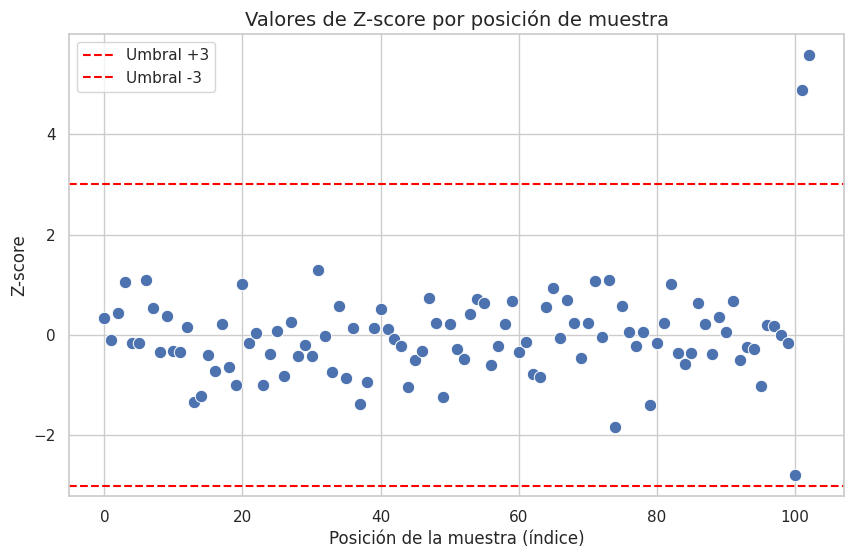

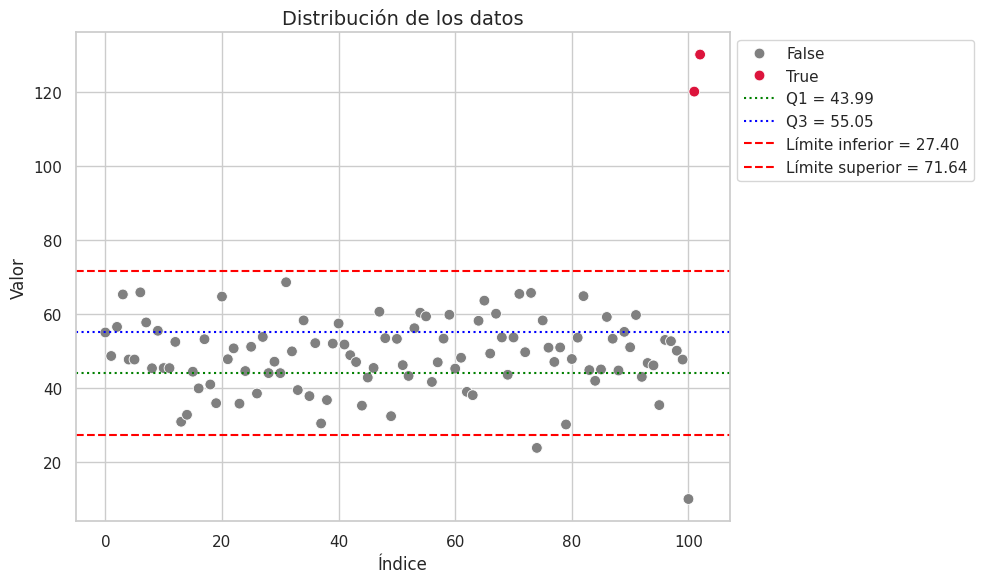

In [58]:
# Calcular Z score
df['z_score'] = zscore(df['valor'])
df['outlier_z'] = df['z_score'].abs() > 3

# Media y desviación estándar global
mu = df['valor'].mean()
sigma = df['valor'].std(ddof=0)

# Calcular z-score 
df['z_score'] = (df['valor'] - mu) / sigma

# Mostrar n muestras 
tabla_muestra = df[['valor', 'z_score']].head(10)
tabla_muestra['media'] = mu
tabla_muestra['desv_est'] = sigma
print(tabla_muestra)

# Crear scatter plot
plt.figure(figsize=(10,6))
sns.scatterplot(x=np.arange(len(df['z_score'])), y=df['z_score'], s=80)

# Líneas horizontales en ±3 (umbral típico de outliers)
plt.axhline(y=3, color='red', linestyle='--', label='Umbral +3')
plt.axhline(y=-3, color='red', linestyle='--', label='Umbral -3')

plt.title("Valores de Z-score por posición de muestra", fontsize=14)
plt.xlabel("Posición de la muestra (índice)", fontsize=12)
plt.ylabel("Z-score", fontsize=12)
plt.legend(loc="upper left")
plt.show()


# Figura
plt.figure(figsize=(10,6))
sns.scatterplot(
    x=range(len(df)), 
    y='valor', 
    hue='outlier_z', 
    data=df,
    palette={False: 'gray', True: 'crimson'}, 
    s=60
)

plt.axhline(Q1, color='green', linestyle=':', label=f'Q1 = {Q1:.2f}')
plt.axhline(Q3, color='blue', linestyle=':', label=f'Q3 = {Q3:.2f}')
plt.axhline(lim_inf, color='red', linestyle='--', label=f'Límite inferior = {lim_inf:.2f}')
plt.axhline(lim_sup, color='red', linestyle='--', label=f'Límite superior = {lim_sup:.2f}')

plt.title('Distribución de los datos', fontsize=14)
plt.xlabel('Índice', fontsize=12)
plt.ylabel('Valor', fontsize=12)
plt.legend(loc='upper left', bbox_to_anchor=(1,1))
plt.tight_layout()
plt.show()




<div style="background-color:#e8f4fd; padding:15px; border-radius:8px; font-size:17px;">

<b>Importante (Z-Score):</b>

- **Dependencia de la distribución normal**: el Z-Score funciona mejor cuando los datos se aproximan a una distribución normal; en distribuciones sesgadas puede fallar en la detección.  
- **Sensibilidad a valores extremos**: los atípicos influyen en la media y en la desviación estándar, lo que puede distorsionar el cálculo de los Z-Scores.  
- **Umbral convencional (|Z| > 3)**: este valor es una regla general; sin embargo, puede ajustarse (ej. usar 2.5 o 4) dependiendo del contexto y del nivel de tolerancia a los atípicos.  
- **Escalado y estandarización**: el método requiere que los datos estén estandarizados para que las comparaciones sean válidas.  
- **Interpretación contextual**: un valor con |Z| elevado no siempre es un error; puede representar un comportamiento excepcional o un fenómeno de interés (ej. un estudiante con rendimiento sobresaliente).  

</div>


# <span style="color:#2F749F;"><strong>3. Test de Grubbs </strong></span>

El **Test de Grubbs**, desarrollado en un trabajo clásico de Grubbs [(1969)](https://www.tandfonline.com/doi/abs/10.1080/00401706.1969.10490657), permite evaluar si el valor más extremo de una muestra corresponde a un outlier bajo el supuesto de normalidad.  
Se define como:

$$
G = \max \left( \frac{|x_i - \bar{x}|}{s} \right)
$$

Donde:

- \( X_i \): valor observado más extremo (mínimo o máximo)  
- \( \bar{X} \): media de la muestra  
- \( s \): desviación estándar de la muestra  

El valor calculado de \(G\) se compara con un valor crítico \(G_{crit}\) de tablas específicas según el tamaño de la muestra y el nivel de significancia [(Ver tabla)](https://webspace.ship.edu/pgmarr/Geo441/Tables/Grubbs%20G%20Outlier%20Test.pdf).

Si \( G > G_{crit} \), el valor extremo se considera atípico.

<div style="background-color:#fff9db; padding:10px; border-radius:5px; font-size:18px;">

<b>Este test es útil para muestras pequeñas con distribución normal, 
pero debe aplicarse con cautela en presencia de múltiples atípicos o datos que no cumplen 
los supuestos de normalidad.</b><br>

</div>


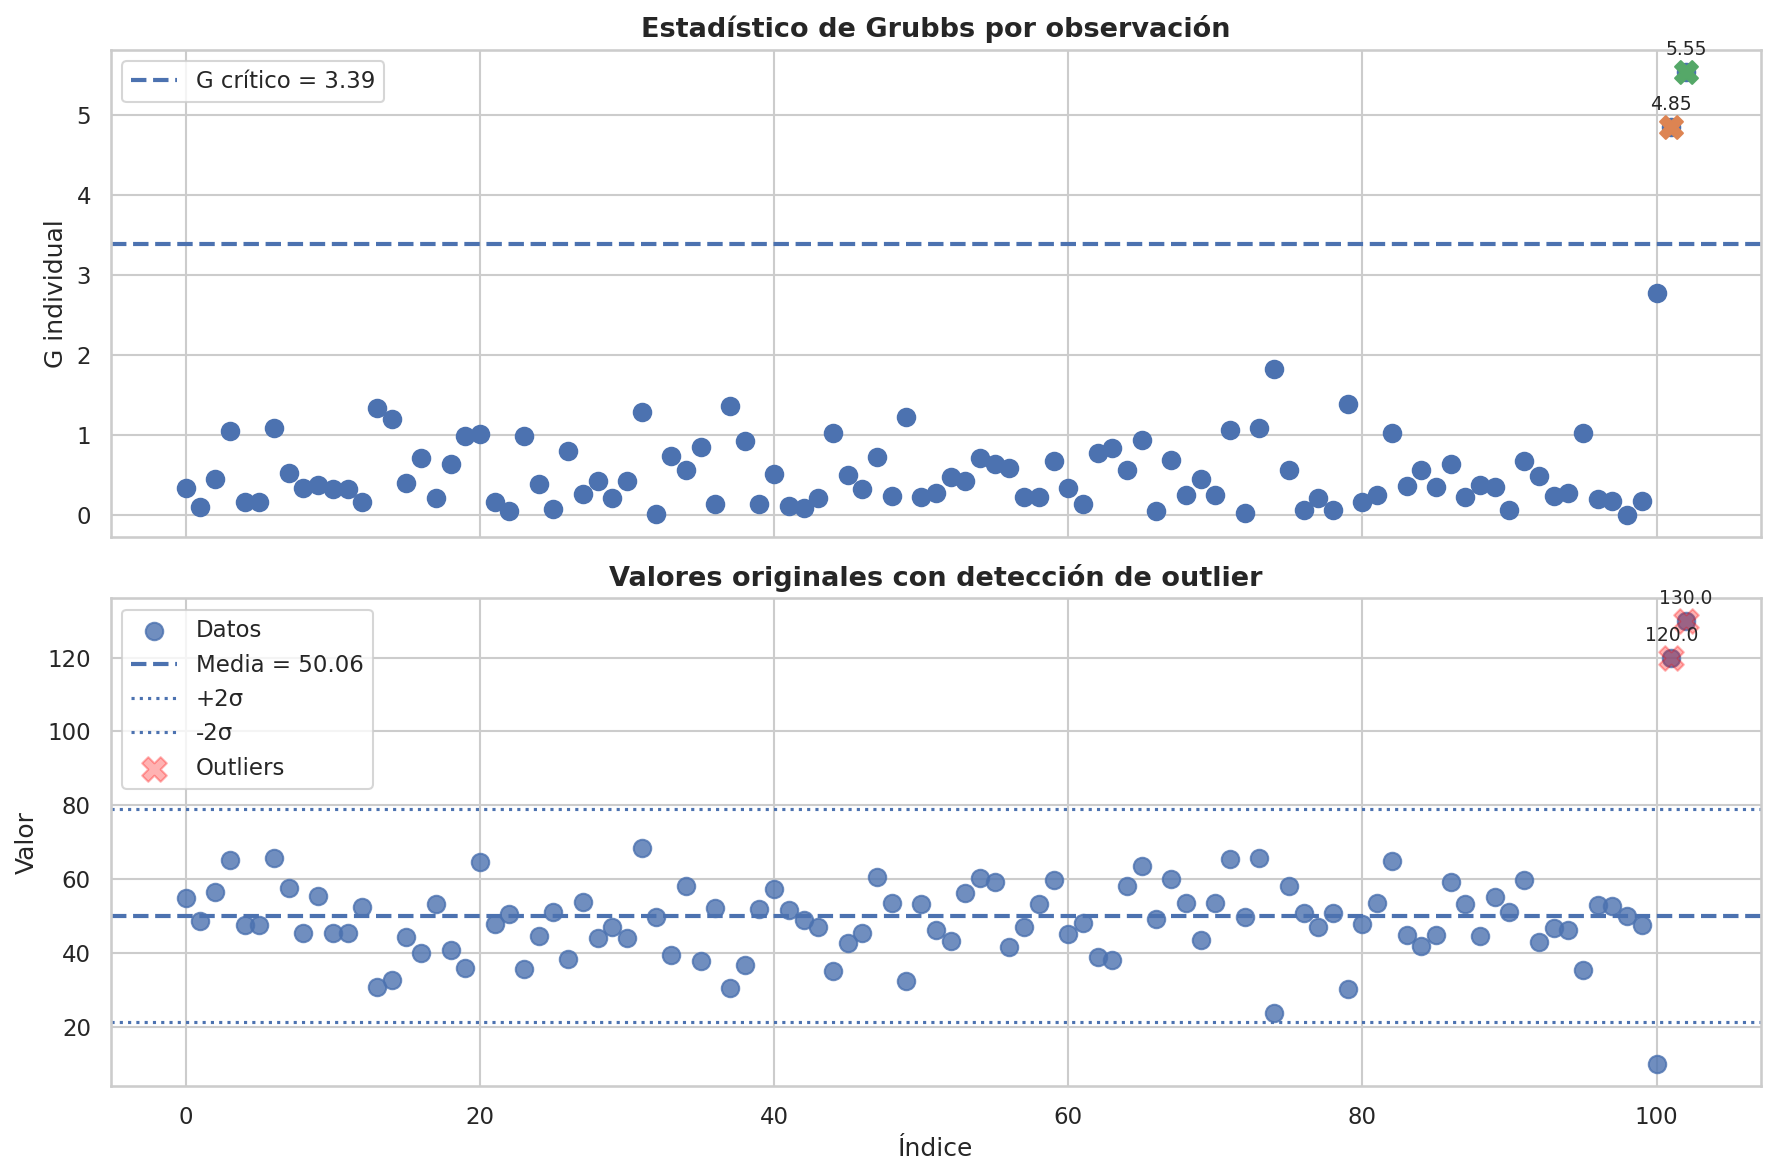

In [59]:
# Estadísticos
data = df['valor']
media = np.mean(data)
std = np.std(data, ddof=1)
n = len(data)

extremo = data[np.argmax(np.abs(data - media))]
G = np.abs(extremo - media) / std

t = stats.t.ppf(1 - 0.05 / (2 * n), n - 2)
G_crit = ((n - 1) / np.sqrt(n)) * np.sqrt(t**2 / (n - 2 + t**2))

G_por_indice = np.abs(data - media) / std

# Gráfico 1: Estadístico G
fig, axes = plt.subplots(2, 1, figsize=(12, 8), dpi=150, sharex=True)
ax = axes[0]

ax.scatter(range(n), G_por_indice, s=70)
ax.axhline(G_crit, linestyle='--', linewidth=2, label=f'G crítico = {G_crit:.2f}')

# resaltar extremos
for i, g in enumerate(G_por_indice):
    if g > G_crit:
        ax.scatter(i, g, s=120, marker='X', zorder=3)
        ax.annotate(f"{g:.2f}",
                    (i, g),
                    textcoords="offset points",
                    xytext=(0,8),
                    ha='center',
                    fontsize=9)

ax.set_title('Estadístico de Grubbs por observación', fontsize=13, weight='bold')
ax.set_ylabel('G individual')
ax.legend(loc='upper left')

# Segundo gráfico
ax = axes[1]

ax.scatter(range(n), data, s=70, alpha=0.8, label='Datos')

# líneas estadísticas
ax.axhline(media, linestyle='--', linewidth=2, label=f'Media = {media:.2f}')
ax.axhline(media + 2*std, linestyle=':', linewidth=1.5, label=f'+2σ')
ax.axhline(media - 2*std, linestyle=':', linewidth=1.5, label=f'-2σ')

# detectar outliers según Grubbs
outliers_idx = np.where(G_por_indice > G_crit)[0]
ax.scatter(
    outliers_idx,
    data[outliers_idx],
    s=140,
    marker='X',
    color='red',
    alpha=0.3,
    zorder=3,
    label='Outliers'
)

for i in outliers_idx:
    ax.annotate(
        f"{data[i]:.1f}",
        (i, data[i]),
        textcoords="offset points",
        xytext=(0,8),
        ha='center',
        fontsize=9
    )

ax.set_title('Valores originales con detección de outlier', fontsize=13, weight='bold')
ax.set_xlabel('Índice')
ax.set_ylabel('Valor')
ax.legend(loc='upper left')

plt.tight_layout()
plt.show()

<div style="background-color:#e8f4fd; padding:15px; border-radius:8px; font-size:17px;">

<b>Importante (Test de Grubbs):</b>

- Requiere que los datos provengan de una **distribución normal**.  
- Diseñado para detectar **un solo atípico por prueba**; si se sospechan múltiples, se deben aplicar versiones iterativas.  
- Es más confiable en **muestras pequeñas o moderadas**, donde otros métodos pueden perder sensibilidad.  
- Puede ser menos adecuado en grandes bases de datos o con distribuciones no normales.  

</div>



# <span style="color:#2F749F;"><strong>4. Método DBSCAN</strong></span>

El algoritmo **DBSCAN (Density-Based Spatial Clustering of Applications with Noise)**, propuesto por Ester et al. [(1996)](https://www.aaai.org/Papers/KDD/1996/KDD96-037.pdf), identifica clústeres de alta densidad y clasifica como outliers a los puntos que no pertenecen a ninguno.  
Un punto \(p\) es **central** si tiene al menos `minPts` vecinos dentro de un radio (ε):

$$
N_\varepsilon(p) = \{\, q \in D \;|\; \mathrm{dist}(p,q) \leq \varepsilon \,\}
$$

El algoritmo depende de dos parámetros clave:  

- **ε (epsilon):** radio máximo de vecindad.  
- **`minPts`** número mínimo de puntos requeridos para formar un clúster.  

DBSCAN es eficaz en datos multivariados, aunque su desempeño depende críticamente de la correcta selección de (ε) y `minPts`.

DBSCAN separa los puntos en tres categorías:  

- **Núcleo (core points):** puntos con suficientes vecinos en un radio definido.  
- **Borde (border points):** puntos cercanos a los núcleos, pero con menos vecinos.  
- **Ruido (outliers):** puntos que no pertenecen a ningún clúster.

Los puntos que no tienen al menos `minPts` vecinos dentro de un radio (ε) se consideran **atípicos o ruido**.  

<div style="background-color:#fff9db; padding:10px; border-radius:5px; font-size:18px;">

<b>Es eficiente en conjuntos de datos grandes y no requiere supuestos de distribución.</b><br>
</div>

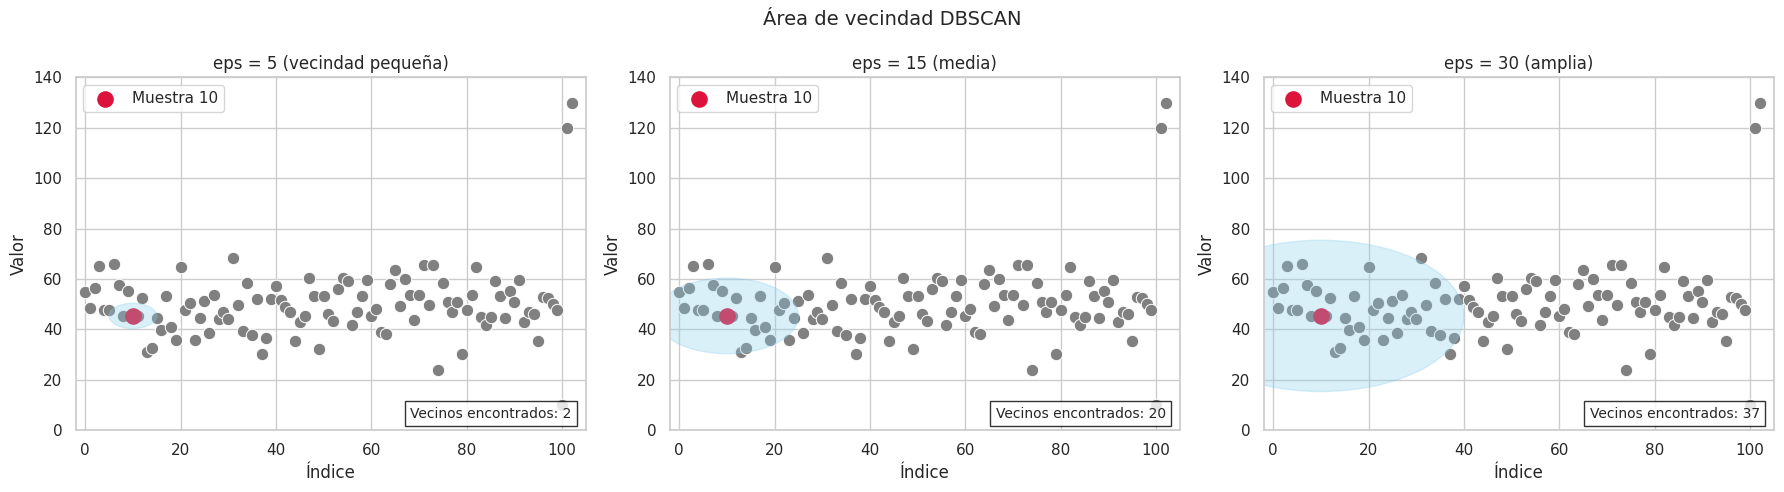

In [ ]:
# Datos
X = np.column_stack([range(len(data)), data])  # índice vs valor
punto_central = X[10]  # muestra número 10

# Comparación
epsilons = [5, 15, 30]
titulos = ['eps = 5 (vecindad pequeña)', 'eps = 15 (media)', 'eps = 30 (amplia)']

# Graficas
fig, axes = plt.subplots(1, 3)

for i, eps in enumerate(epsilons):
    ax = axes[i]
    sns.scatterplot(x=X[:, 0], y=X[:, 1], ax=ax, s=80, color='gray')
    ax.scatter(*punto_central, color='crimson', s=120, label='Muestra 10')

    # vecindad
    circulo = Circle(punto_central, eps, color='skyblue', alpha=0.3)
    ax.add_patch(circulo)

    # vecinos dentro del círculo
    distancias = np.linalg.norm(X - punto_central, axis=1)
    vecinos = np.sum(distancias <= eps) - 1  # excluye el punto central

    ax.set_title(titulos[i])
    ax.set_xlabel('Índice')
    ax.set_ylabel('Valor')
    ax.set_xlim(-2, len(data) + 2)
    ax.set_ylim(min(data) - 10, max(data) + 10)
    ax.text(len(data) - 1, min(data) - 5,
            f"Vecinos encontrados: {vecinos}",
            fontsize=10,
            ha='right',
            bbox=dict(facecolor='white', edgecolor='black', alpha=0.8))
    ax.legend(loc='upper left')

plt.suptitle('Área de vecindad DBSCAN', fontsize=14)
plt.tight_layout()
plt.show()


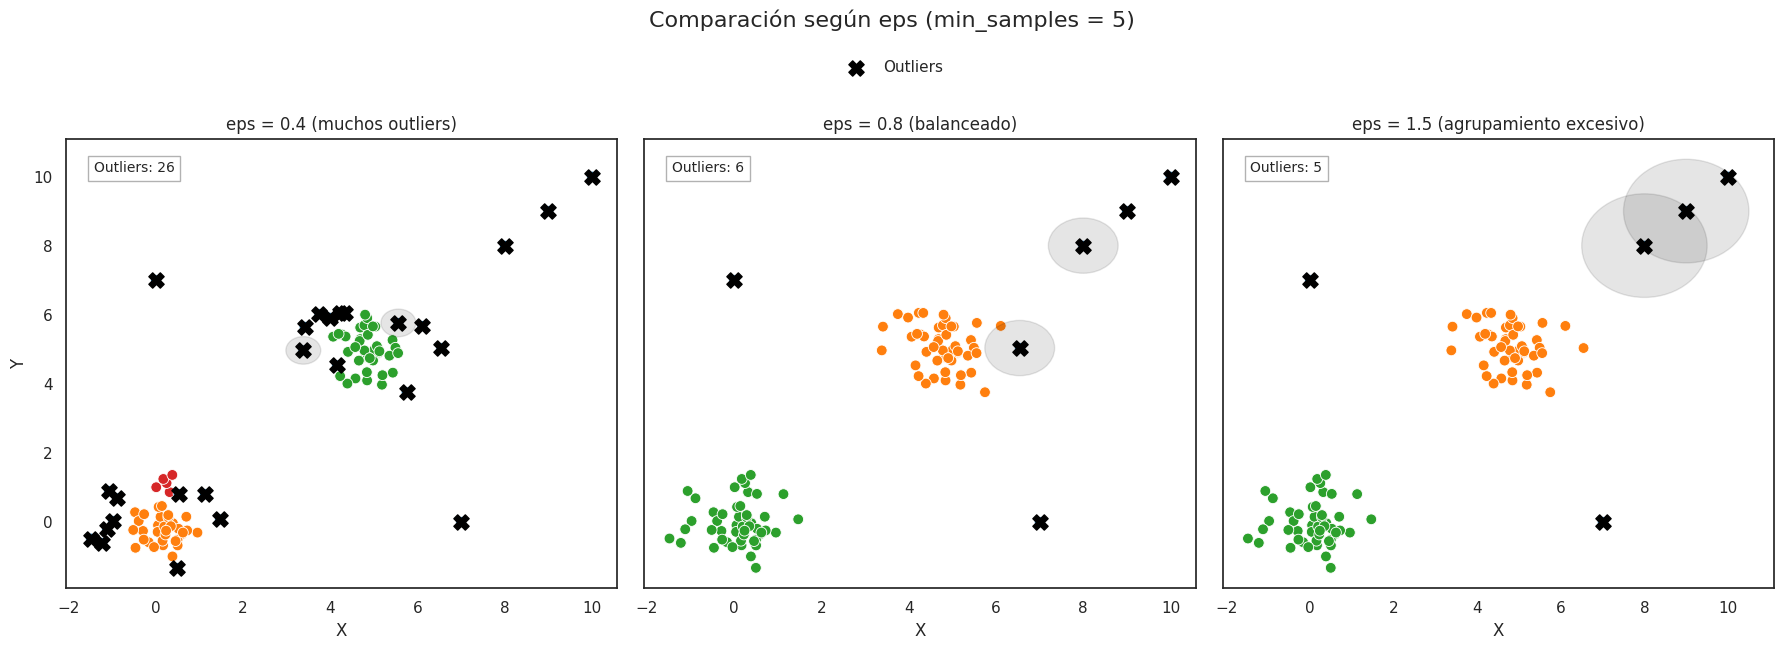

In [73]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_blobs
from matplotlib.patches import Circle

# Simulación de datos 
centros = [[0, 0], [5, 5]]
X, _ = make_blobs(n_samples=100, centers=centros, cluster_std=0.6)
outliers = np.array([[8, 8], [9, 9], [10, 10], [0, 7], [7, 0]])
X_total = np.vstack([X, outliers])

# Valores de eps
epsilons = [0.4, 0.8, 1.5]
titulos = ['eps = 0.4 (muchos outliers)', 
           'eps = 0.8 (balanceado)', 
           'eps = 1.5 (agrupamiento excesivo)']

# Graficar
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for i, eps in enumerate(epsilons):
    modelo = DBSCAN(eps=eps, min_samples=5)
    etiquetas = modelo.fit_predict(X_total)

    # Scatterplot
    sns.scatterplot(x=X_total[:, 0], y=X_total[:, 1], hue=etiquetas,
                    palette='tab10', s=60, ax=axes[i], legend=False)

    # Resaltar todos los outliers
    outlier_indices = np.where(etiquetas == -1)[0]
    axes[i].scatter(X_total[outlier_indices, 0], 
                    X_total[outlier_indices, 1],
                    color='black', s=120, marker='X', label='Outliers')

    # Dibujar círculos de radio eps alrededor de algunos outliers
    for idx in outlier_indices[:2]:  # solo los primeros 2 para no saturar
        punto = X_total[idx]
        sombra = Circle(punto, radius=eps, color='black', alpha=0.1)
        axes[i].add_patch(sombra)

    axes[i].set_title(titulos[i], fontsize=12)
    axes[i].set_xlabel('X')
    if i == 0:
        axes[i].set_ylabel('Y')
    else:
        axes[i].set_ylabel('')

    # Texto con número de outliers
    axes[i].text(0.05, 0.95,
                 f"Outliers: {(etiquetas == -1).sum()}",
                 transform=axes[i].transAxes,
                 fontsize=10,
                 ha='left',
                 va='top',
                 bbox=dict(facecolor='white', edgecolor='gray', alpha=0.6))

# Leyenda global
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels,
           loc='upper center',
           bbox_to_anchor=(0.5, 1.02),
           ncol=2,
           frameon=False)

plt.suptitle('Comparación según eps (min_samples = 5)', fontsize=16, y=1.08)
plt.tight_layout()
plt.show()


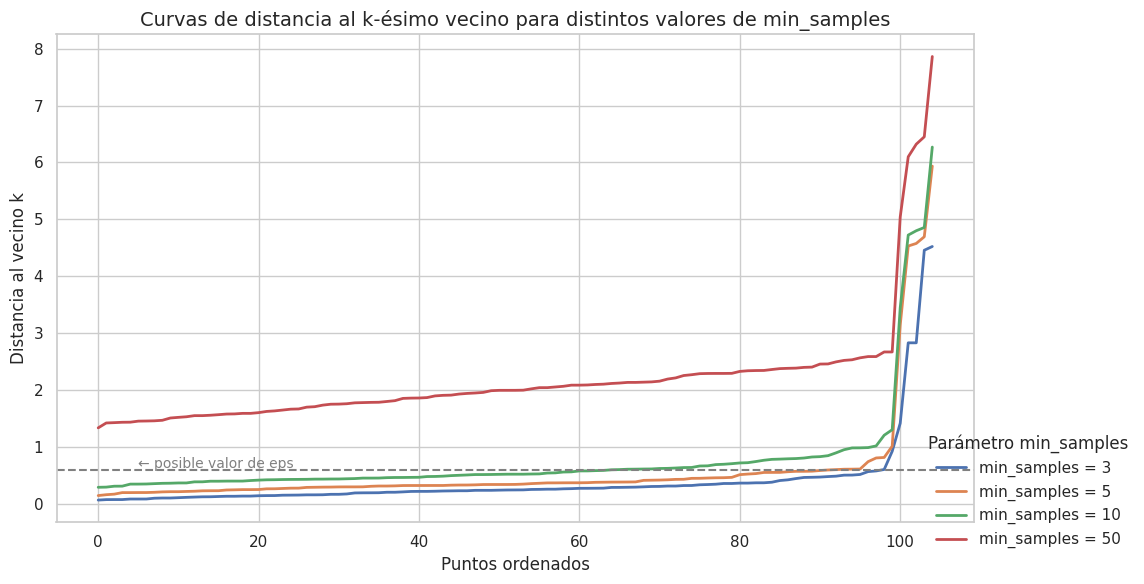

In [62]:
fig = plt.figure(figsize=(10, 6))

# Simulación de datos
np.random.seed(42)
centros = [[0, 0], [5, 5]]
X, _ = make_blobs(n_samples=100, centers=centros, cluster_std=0.6)
outliers = np.array([[8, 8], [9, 9], [10, 10], [0, 7], [7, 0]])
X_total = np.vstack([X, outliers])

# Comparación de epsilón
vecinos_k = [3, 5, 10, 50]

for k in vecinos_k:
    modelo = NearestNeighbors(n_neighbors=k)
    modelo.fit(X_total)
    distancias, _ = modelo.kneighbors(X_total)
    
    # distancia al k-ésimo vecino más cercano
    distancia_k = np.sort(distancias[:, -1])
    plt.plot(distancia_k, label=f'min_samples = {k}', linewidth=2)

plt.title('Curvas de distancia al k-ésimo vecino para distintos valores de min_samples', fontsize=14)
plt.xlabel('Puntos ordenados')
plt.ylabel('Distancia al vecino k')
plt.grid(True)
leg = fig.legend(title='Parámetro min_samples',
                 loc='lower right',
                 bbox_to_anchor=(1.15, 0.05),  
                 frameon=False)
plt.axhline(y=0.6, color='gray', linestyle='--', label='Ejemplo de eps = 0.6')
plt.text(5, 0.62, '← posible valor de eps', fontsize=10, color='gray')
plt.tight_layout()
plt.show()



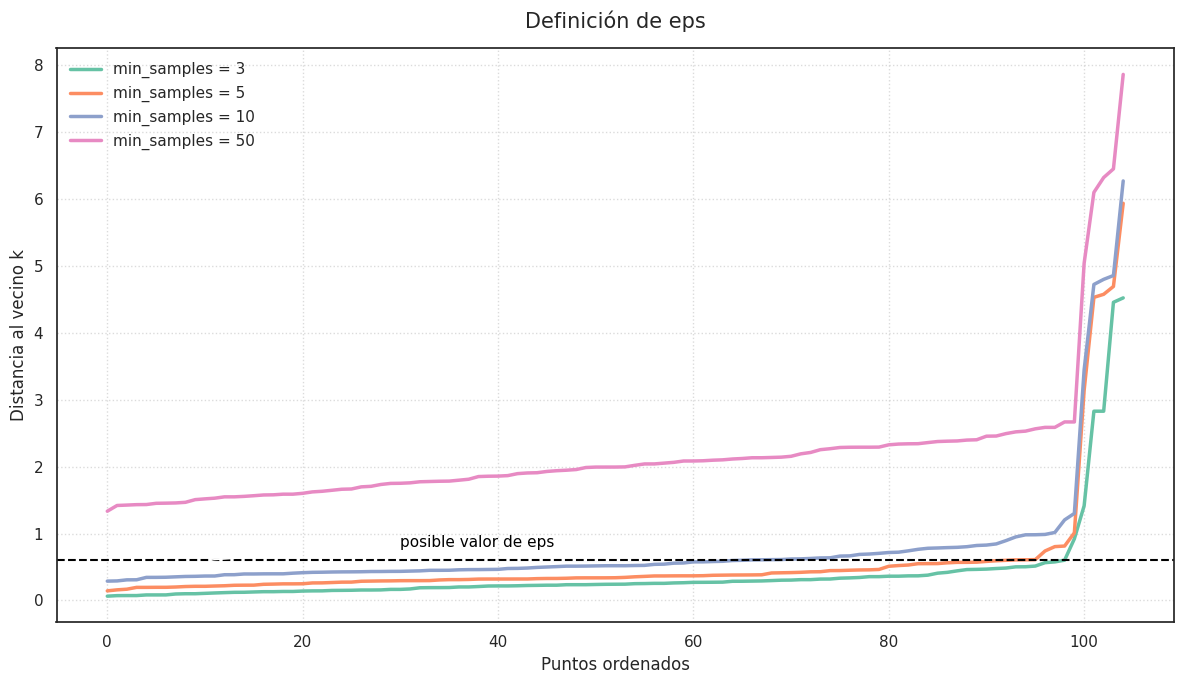

In [77]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs
from sklearn.neighbors import NearestNeighbors

# Simulación de datos
np.random.seed(42)
centros = [[0, 0], [5, 5]]
X, _ = make_blobs(n_samples=100, centers=centros, cluster_std=0.6)
outliers = np.array([[8, 8], [9, 9], [10, 10], [0, 7], [7, 0]])
X_total = np.vstack([X, outliers])

# Comparación de epsilón
vecinos_k = [3, 5, 10, 50]
colores = sns.color_palette("Set2", len(vecinos_k))

plt.figure(figsize=(12, 7))

for k, color in zip(vecinos_k, colores):
    modelo = NearestNeighbors(n_neighbors=k)
    modelo.fit(X_total)
    distancias, _ = modelo.kneighbors(X_total)
    
    # distancia al k-ésimo vecino más cercano
    distancia_k = np.sort(distancias[:, -1])
    plt.plot(distancia_k, label=f'min_samples = {k}', 
             linewidth=2.5, color=color)

# Línea de referencia eps
eps_val = 0.6
plt.axhline(y=eps_val, color='black', linestyle='--', linewidth=1.5)
plt.annotate('posible valor de eps',
             xy=(10, eps_val), xytext=(30, eps_val+0.2),
             arrowprops=dict(facecolor='gray', arrowstyle='->'),
             fontsize=11, color='black')

# Estética general
plt.title('Definición de eps', fontsize=15, pad=15)
plt.xlabel('Puntos ordenados', fontsize=12)
plt.ylabel('Distancia al vecino k', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(loc='upper left', frameon=False)
plt.tight_layout()
plt.show()


<div style="background-color:#e8f4fd; padding:15px; border-radius:8px; font-size:17px;">

<b>Importante (DBSCAN):</b>

- No requiere especificar el número de clústeres previamente.  
- Detecta atípicos de manera natural al clasificar los puntos de baja densidad como ruido.  
- Es robusto frente a distribuciones no esféricas y datos con formas arbitrarias.  
- La calidad de la detección depende en gran medida de la elección de los parámetros **ε** y **MinPts**.  
- Puede tener dificultades en datasets con densidades variables o en muy altas dimensiones.  

</div>


# <span style="color:#2F749F;"><strong>5. Isolation Forest</strong></span>

El **Isolation Forest**, introducido por Liu, Ting y Zhou [(2008)](https://ieeexplore.ieee.org/document/4781136), se basa en la idea de que los **outliers son más fáciles de aislar** que los puntos normales.  
El algoritmo construye múltiples **árboles de aislamiento aleatorio**, y la longitud promedio del camino que sigue un punto sirve como indicador:  
- Los **outliers** suelen tener **caminos más cortos**.  
- Los puntos normales tienen **caminos más largos**.  

Es altamente escalable, eficiente en grandes volúmenes de datos y adecuado para alta dimensionalidad.

<p align="center">
    <img src="Local\imgs\U2\solation-Forest-for-anomaly-detection.jpg" alt="isolation" width="900"  height="400">
</p>

Imagen tomada de [researchgate.net](https://www.researchgate.net/figure/solation-Forest-for-anomaly-detection_fig1_365288037)


<span style="color:black;"><strong>Ecuaciones</strong></span>

## **1. Longitud promedio del camino de un punto**

$$
E(h(x)) = \frac{1}{t} \sum_{i=1}^{t} h_i(x)
$$

Cada vez que ponemos un punto \(x\) en un árbol, medimos cuántas **divisiones (splits)** necesitó el árbol para aislarlo.  
- \(h_i(x)\): longitud del camino en el árbol \(i\).  
- \(t\): número de árboles en el bosque.  

→ Los **outliers** suelen tener caminos más cortos porque se aíslan rápido.  


## **2. Normalización de la longitud de camino**

$$
c(n) = 2H(n-1) - \frac{2(n-1)}{n}
$$

Aquí se calcula un **factor de ajuste** para que podamos comparar caminos en bosques de distintos tamaños.  
- \(n\): número de puntos en el dataset.  
- \(H(i)\): número armónico (aprox. \(\ln(i) + \gamma\)).  

→ Esto estandariza el promedio de caminos esperados en un dataset de tamaño \(n\).  



## **3. Score de anomalía**

$$
s(x, n) = 2^{-\frac{E(h(x))}{c(n)}}
$$

Este es el puntaje final de anomalía:  
- Si el camino \(E(h(x))\) es **corto** → \(s(x,n) tiende a 1\) → **probable outlier**.  
- Si el camino \(E(h(x))\) es **largo** → \(s(x,n) tiende a 0\) → **punto normal**.  



**Resumen:**  
1. Se mide cuántas divisiones toma aislar un punto.  
2. Se normaliza con el tamaño del dataset.  
3. Se obtiene un score:  
   - \(s(x,n) \to 1\) → outlier.  
   - \(s(x,n) \to 0\) → normal.  


<div style="background-color:#fff9db; padding:10px; border-radius:5px; font-size:18px;">

<b>Es eficiente en conjuntos de datos grandes y no requiere supuestos de distribución.</b><br>
</div>


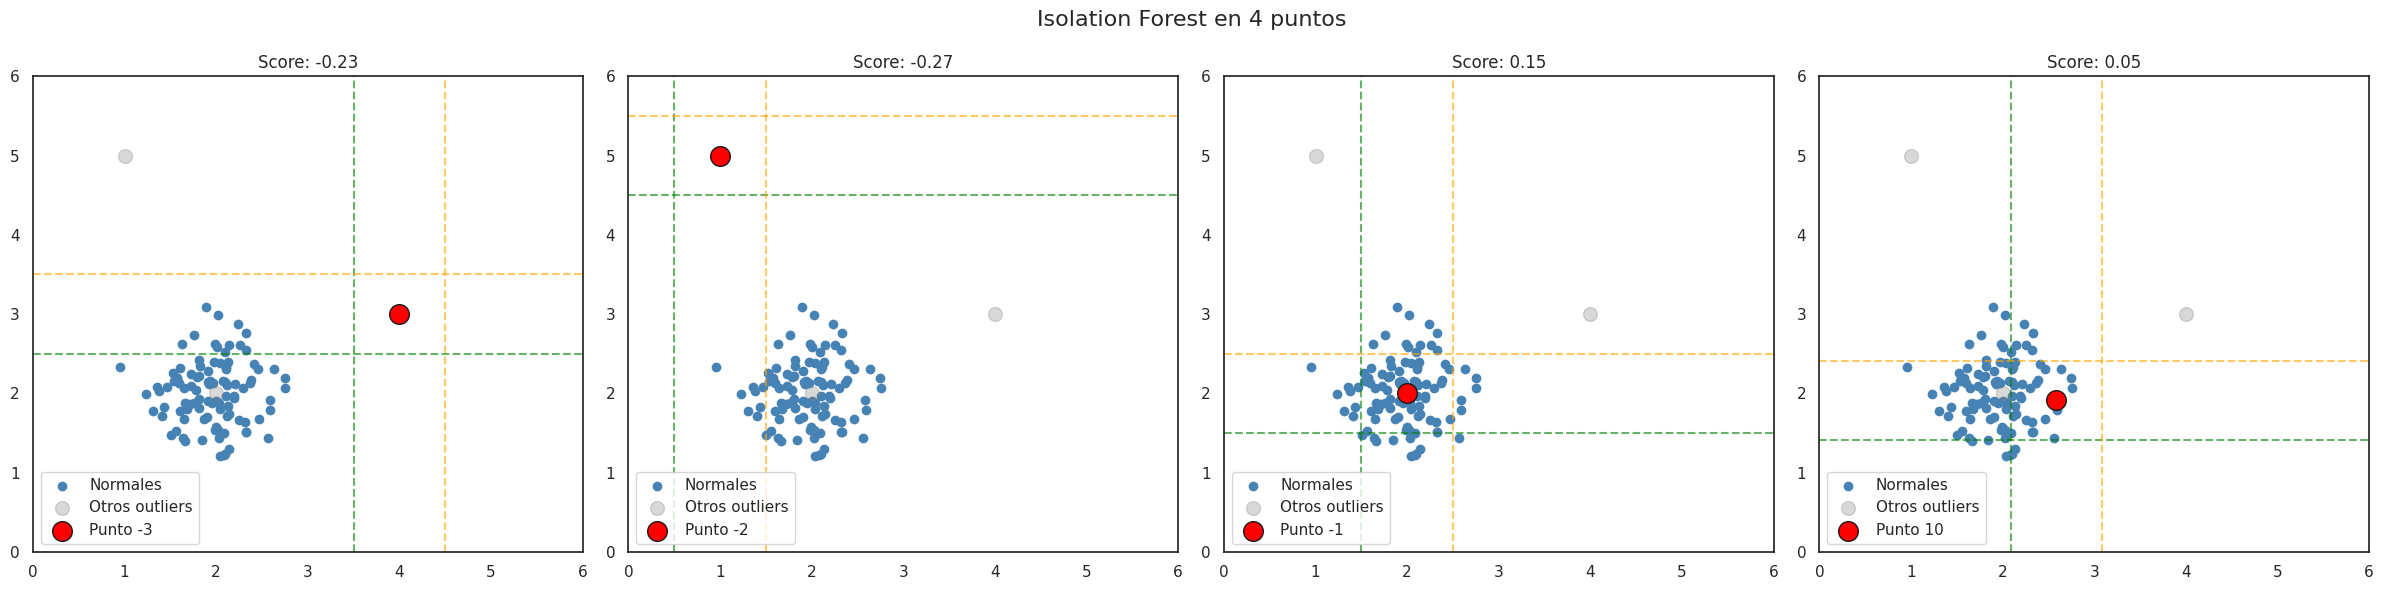

In [87]:
from sklearn.ensemble import IsolationForest

# Simular datos
np.random.seed(42)
X_normal = np.random.randn(100, 2) * 0.4 + [2, 2]
X_outliers = np.array([[4, 3], [1, 5], [2, 2]])  # tres outliers
X = np.vstack([X_normal, X_outliers])

# Isolation Forest
iso = IsolationForest(contamination=0.05, random_state=42)
y_pred = iso.fit_predict(X)
scores = iso.decision_function(X)  # mayor score = más anómalo

# Índices de puntos a analizar: 3 outliers + 1 punto normal
puntos_candidatos = [-3, -2, -1, 10]  # último es un punto normal

# Visualización
fig, axes = plt.subplots(1, 4, figsize=(24, 6))

for i, idx in enumerate(puntos_candidatos):
    p = X[idx].reshape(1, -1)
    ax = axes[i]

    ax.scatter(X[:-3, 0], X[:-3, 1], c="steelblue", label="Normales")
    ax.scatter(X_outliers[:, 0], X_outliers[:, 1], c="gray", label="Otros outliers", s=100, alpha=0.3)
    ax.scatter(p[:, 0], p[:, 1], c="red", s=200, edgecolors="k", label=f"Punto {idx}")

    ax.axvline(x=p[0, 0] - 0.5, color="green", linestyle="--", alpha=0.6)
    ax.axhline(y=p[0, 1] - 0.5, color="green", linestyle="--", alpha=0.6)
    ax.axvline(x=p[0, 0] + 0.5, color="orange", linestyle="--", alpha=0.6)
    ax.axhline(y=p[0, 1] + 0.5, color="orange", linestyle="--", alpha=0.6)

    ax.set_title(f"Score: {scores[idx]:.2f}")
    ax.legend(loc='lower left')
    ax.set_xlim(0, 6)
    ax.set_ylim(0, 6)

plt.suptitle("Isolation Forest en 4 puntos", fontsize=16)
plt.tight_layout()
plt.show()


<div style="background-color:#e8f4fd; padding:15px; border-radius:8px; font-size:17px;"> 

<b>Importante (Isolation Forest):</b>

- Escalable a grandes volúmenes de datos.  
- No requiere normalidad ni suposiciones paramétricas.  
- Los atípicos suelen aislarse en menos divisiones que los datos normales.  
- Funciona bien en espacios de alta dimensión.  
- Su desempeño depende de la cantidad de árboles y profundidad máxima establecida.  

</div>

# <span style="color:#2F749F;"><strong>6. Local Outlier Factor (LOF)</strong></span>

El **Local Outlier Factor (LOF)**, propuesto por Breunig, Kriegel, Ng y Sander [(2000)](https://dl.acm.org/doi/10.1145/342009.335388), detecta anomalías a partir de la **densidad relativa local**.  
Un punto se considera outlier si su densidad es significativamente menor que la de sus vecinos:

- Los puntos en regiones de baja densidad relativa reciben un **LOF alto** → considerados outliers.  
- Los puntos en regiones homogéneas → **LOF cercano a 1** → considerados normales.

<span style="color:black;"><strong>Ecuaciones</strong></span>

## **1. Distancia de k-vecinos más cercanos** de un punto p:

$$
k\text{-dist}(p) = \text{distancia al }k\text{-ésimo vecino más cercano de } p
$$

→  Esto mide **qué tan lejos está el último de los k-vecinos más cercanos** de un punto *p*. Es como fijar el “radio de vecindad” para ese punto.  


## **2. Alcanzabilidad** de un **punto p** respecto a un **vecino o**:
$$
\text{reach-dist}_k(p, o) = \max \big( k\text{-dist}(o), \, dist(p, o) \big)
$$

donde:
- dist(p, o): distancia euclidiana entre p y o
- dist(o): distancia al k-ésimo vecino más cercano de o

→  Ajusta la distancia real entre \(p\) y \(o\).  Si están demasiado cerca, usamos el **mínimo permitido** (\(k\)-distancia de \(o\)), para evitar valores muy pequeños que distorsionen los cálculos.  



## **3. Densidad local alcanzable** (LRD) de un punto p:

$$
LRD_k(p) = \frac{1}{\frac{1}{|N_k(p)|} \sum_{o \in N_k(p)} \text{reach-dist}_k(p, o)}
$$

donde:  
- N_k(p) es el conjunto de k-vecinos más cercanos de p.  
- |N_k(p)|: número de vecinos (normalmente igual a k)

→  Mide **qué tan apretado está el vecindario de \(p\)**.  
- Calculamos el **promedio de las distancias alcanzables** entre \(p\) y sus \(k\) vecinos.  
- Luego tomamos el inverso → a **menor distancia**, mayor densidad.  

## **4. Factor de outlier local (LOF):**

$$
LOF_k(p) = \frac{1}{|N_k(p)|} \sum_{o \in N_k(p)} \frac{LRD_k(o)}{LRD_k(p)}
$$

→ Compara la densidad de \(p\) con la de sus vecinos:  
- Si las densidades son similares → \(\frac{LRD_k(o)}{LRD_k(p)} \approx 1\).  
- Si \(p\) es mucho **menos denso** que sus vecinos → el cociente es **> 1** → \(p\) es un **outlier**.  
- Si \(p\) está en una zona más densa que sus vecinos → LOF < 1.  


**Interpretación:**
- LOF_k(p) approx 1 → punto normal.  
- LOF_k(p) > 1 → posible outlier (a mayor valor, mayor rareza).  
- LOF_k(p) < 1 → punto más denso que sus vecinos.  


**Resumen:**  
1. Se mide el radio de vecindad de cada punto.  
2. Se ajustan las distancias muy pequeñas.  
3. Se calcula la densidad local alcanzable (LRD).  
4. Se compara la densidad del punto con la de sus vecinos → si es mucho menor, se considera outlier.  

<div style="background-color:#fff9db; padding:10px; border-radius:5px; font-size:18px;">

<b>Es útil cuando los atípicos se definen en relación con la vecindad local más que con el conjunto global.</b><br>
</div>


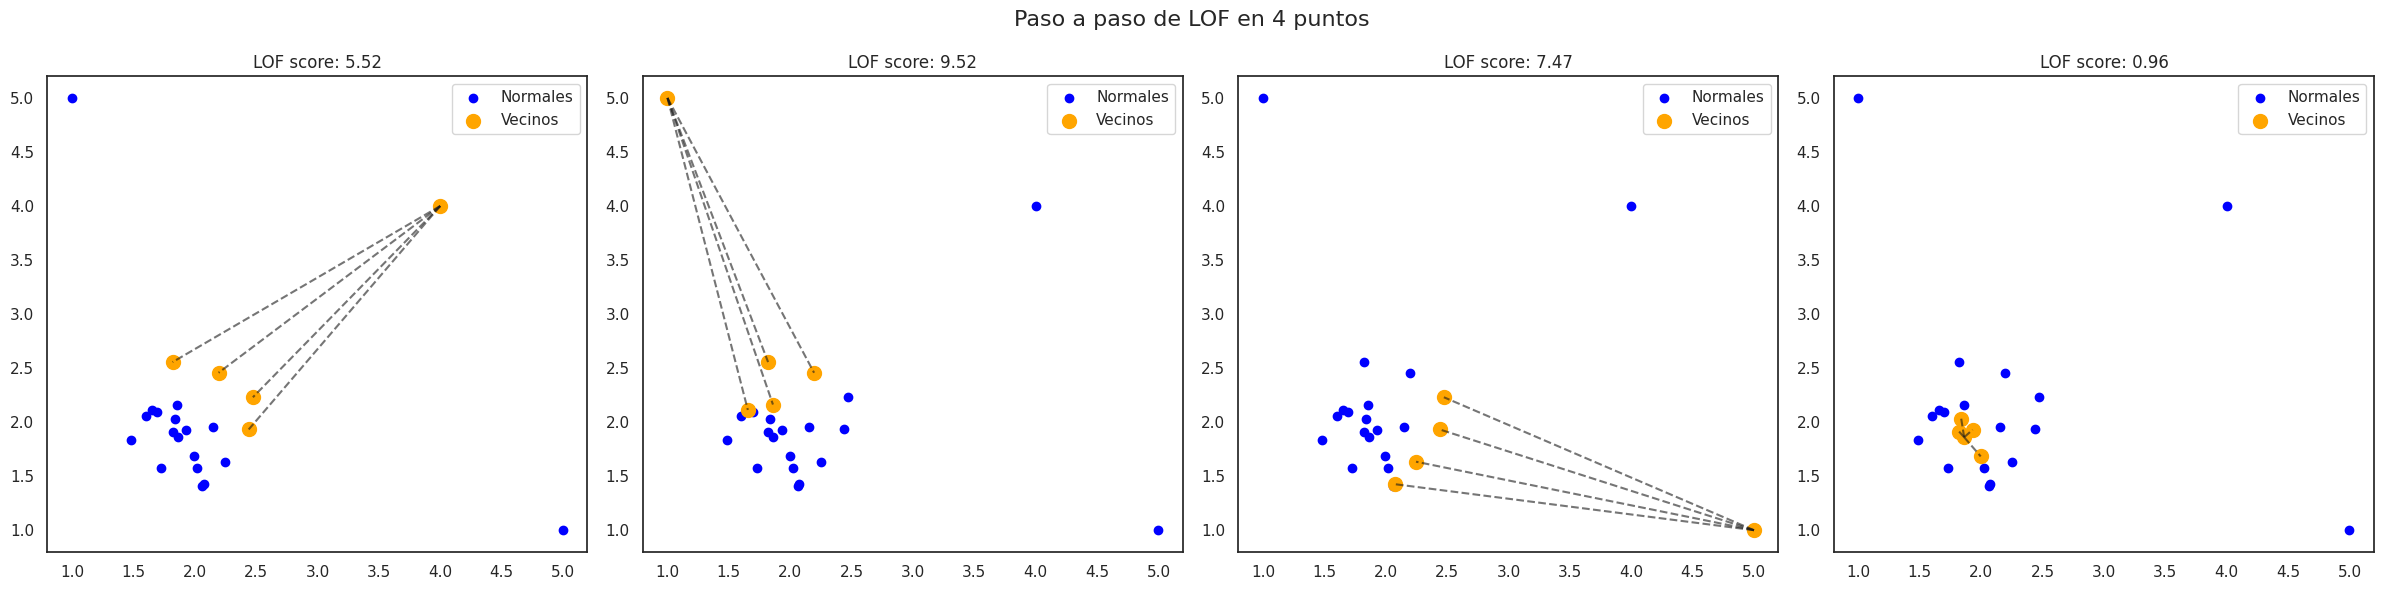

In [79]:
from sklearn.neighbors import LocalOutlierFactor, NearestNeighbors

# Simular datos 
np.random.seed(42)
X_normal = np.random.randn(20, 2) * 0.3 + [2, 2]
X_outliers = np.array([[4, 4], [1, 5], [5, 1]])  # tres outliers
X = np.vstack([X_normal, X_outliers])

# Aplicar LOF
lof = LocalOutlierFactor(n_neighbors=5)
y_pred = lof.fit_predict(X)
scores = -lof.negative_outlier_factor_

# Índices de puntos a analizar: 3 outliers + 1 punto normal
puntos_candidatos = [-3, -2, -1, 5]  # último es un punto normal

# Visualización
fig, axes = plt.subplots(1, 4, figsize=(24, 6))
for i, idx in enumerate(puntos_candidatos):
    p = X[idx].reshape(1, -1)
    nn = NearestNeighbors(n_neighbors=5).fit(X)
    distances, indices = nn.kneighbors(p)

    ax = axes[i]
    ax.scatter(X[:, 0], X[:, 1], c='blue', label="Normales")
    #ax.scatter(p[:, 0], p[:, 1], c='red', label=f"Punto {idx}", s=150, edgecolors="k")
    ax.scatter(X[indices[0], 0], X[indices[0], 1], c='orange', label="Vecinos", s=100)

    for j in indices[0]:
        ax.plot([p[0, 0], X[j, 0]], [p[0, 1], X[j, 1]], 'k--', alpha=0.6)

    #ax.set_title(f"Punto {idx} vs vecinos\nLOF score: {scores[idx]:.2f}")
    ax.set_title(f"LOF score: {scores[idx]:.2f}")
    ax.legend()

plt.suptitle("Paso a paso de LOF en 4 puntos", fontsize=16)
plt.tight_layout()
plt.show()


<div style="background-color:#e8f4fd; padding:15px; border-radius:8px; font-size:17px;"> 

<b>Interpretación (LOF):</b>

- LOF_k(p) approx 1 → punto normal.  
- LOF_k(p) > 1 → posible outlier (a mayor valor, mayor rareza).  
- LOF_k(p) < 1 → punto más denso que sus vecinos.  

**Importante:**
- Detecta atípicos locales que no serían evidentes en un análisis global.  
- No asume forma específica de distribución.  
- Sensible a la elección del parámetro **k** (número de vecinos).  
- Puede verse afectado por ruido y alta dimensionalidad.  
- Es más adecuado para datasets de tamaño mediano.  
</div>


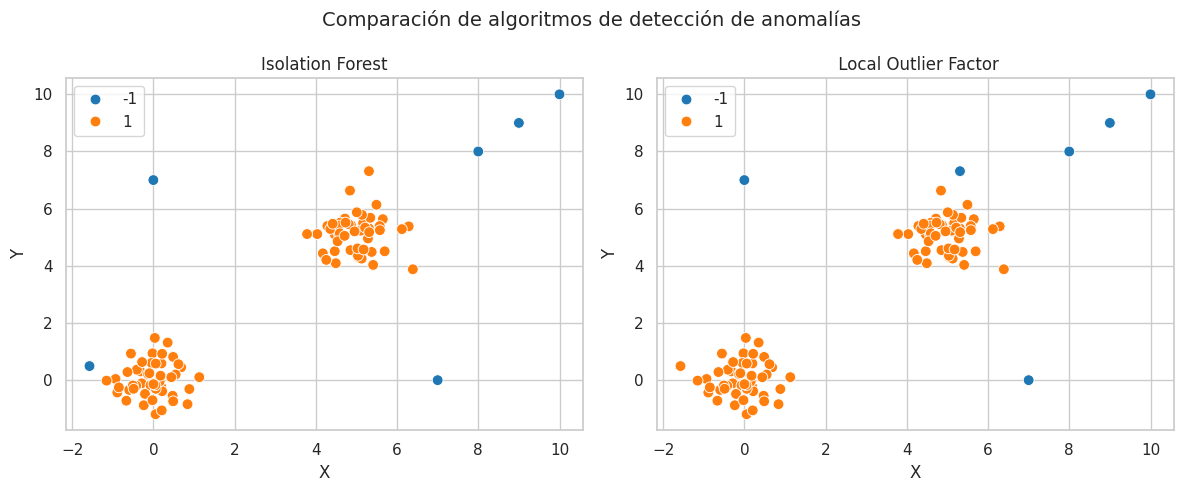

In [65]:
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

# Simular datos
centros = [[0, 0], [5, 5]]
X, _ = make_blobs(n_samples=100, centers=centros, cluster_std=0.6)
outliers = np.array([[8, 8], [9, 9], [10, 10], [0, 7], [7, 0]])
X_total = np.vstack([X, outliers])

# Modelo Isolation Forest
modelo_if = IsolationForest(contamination=0.05, random_state=42)
etiquetas_if = modelo_if.fit_predict(X_total)  # 1 = normal, -1 = outlier

# Modelo LOF
modelo_lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
etiquetas_lof = modelo_lof.fit_predict(X_total)  # 1 = normal, -1 = outlier

# Visualización 
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.scatterplot(x=X_total[:, 0], y=X_total[:, 1], hue=etiquetas_if,
                palette='tab10', s=60, ax=axes[0])
axes[0].set_title('Isolation Forest')
axes[0].set_xlabel('X')
axes[0].set_ylabel('Y')

sns.scatterplot(x=X_total[:, 0], y=X_total[:, 1], hue=etiquetas_lof,
                palette='tab10', s=60, ax=axes[1])
axes[1].set_title(' Local Outlier Factor')
axes[1].set_xlabel('X')
axes[1].set_ylabel('Y')

plt.suptitle('Comparación de algoritmos de detección de anomalías', fontsize=14)
plt.tight_layout()
plt.show()


---

<div style="text-align:center; color:#607D8B; font-weight:bold; font-size:14px;">
“Sin datos, solo eres otra persona con una opinión.” – W. Edwards Deming
</div>